# Selected Best Model Forecast Plots

This notebook plots the selected best models used in the presentation:

- AAPL: StatsForecast Tier 1 AutoARIMA, StatsForecast Tier 1 AutoRegressive, PECNet Tier 4
- BMW.DE: StatsForecast Tier 2 AutoARIMA, StatsForecast Tier 2 AutoRegressive, PECNet Tier 5

It first tries to read forecast and actual values from MLflow artifact tables. If MLflow is not available, it falls back to the local forecast PNGs in the `artifacts` folder.

In [12]:
from __future__ import annotations

import json
import os
import re
import tempfile
from pathlib import Path
from typing import Any

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

try:
    import mlflow
    from mlflow.tracking import MlflowClient
except Exception as exc:
    mlflow = None
    MlflowClient = None
    print(f"MLflow import failed. Local PNG fallback will be used. Error: {exc!r}")

pd.options.display.max_columns = 120
plt.style.use("seaborn-v0_8-whitegrid")


In [13]:
PROJECT_ROOT = Path(
    "/Users/batuhansaylam/Documents/Codex/2026-07-04/a/outputs/"
    "yahooquery_lakehouse_revamp"
).expanduser().resolve()
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "stock_close_training"

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5001")
os.environ.setdefault("MLFLOW_S3_ENDPOINT_URL", "http://127.0.0.1:9000")
os.environ.setdefault("AWS_ACCESS_KEY_ID", "admin")
os.environ.setdefault("AWS_SECRET_ACCESS_KEY", "admin1234")
os.environ.setdefault("AWS_DEFAULT_REGION", "us-east-1")

SELECTED_MODELS = [
    {
        "ticker": "AAPL",
        "family": "statsforecast",
        "tier": "tier1",
        "model": "AutoARIMA",
        "label": "AAPL | AutoARIMA | Tier 1",
    },
    {
        "ticker": "AAPL",
        "family": "statsforecast",
        "tier": "tier1",
        "model": "AutoRegressive",
        "label": "AAPL | AutoRegressive | Tier 1",
    },
    {
        "ticker": "AAPL",
        "family": "pecnet",
        "tier": "tier4",
        "model": "PECNet",
        "label": "AAPL | PECNet | Tier 4",
    },
    {
        "ticker": "BMW.DE",
        "family": "statsforecast",
        "tier": "tier2",
        "model": "AutoARIMA",
        "label": "BMW.DE | AutoARIMA | Tier 2",
    },
    {
        "ticker": "BMW.DE",
        "family": "statsforecast",
        "tier": "tier2",
        "model": "AutoRegressive",
        "label": "BMW.DE | AutoRegressive | Tier 2",
    },
    {
        "ticker": "BMW.DE",
        "family": "pecnet",
        "tier": "tier5",
        "model": "PECNet",
        "label": "BMW.DE | PECNet | Tier 5",
    },
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT}")
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")


Project root: /Users/batuhansaylam/Documents/Codex/2026-07-04/a/outputs/yahooquery_lakehouse_revamp
Artifact root: /Users/batuhansaylam/Documents/Codex/2026-07-04/a/outputs/yahooquery_lakehouse_revamp/artifacts/stock_close_training
MLflow tracking URI: http://127.0.0.1:5001


In [14]:
def safe_name(value: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_.-]+", "_", str(value))


def tier_experiment_name(tier: str) -> str:
    return f"stock_close_{tier}"


def expected_run_name(selection: dict[str, str]) -> str:
    tier = selection["tier"]
    if selection["family"] == "statsforecast":
        return f"stock-close-{tier}-statsforecast"
    if selection["family"] == "pecnet":
        return f"pecnet-{tier}-{safe_name(selection['ticker'])}"
    raise ValueError(f"Unsupported family: {selection['family']}")


def predictions_artifact_path(selection: dict[str, str]) -> str:
    tier = selection["tier"]
    if selection["family"] == "statsforecast":
        return f"statsforecast/{tier}/evaluation/predictions.json"
    return f"pecnet/{tier}/predictions/{selection['ticker']}.json"


def train_artifact_path(selection: dict[str, str]) -> str:
    tier = selection["tier"]
    if selection["family"] == "statsforecast":
        return f"statsforecast/{tier}/datasets/train.json"
    return f"pecnet/{tier}/tickers/{safe_name(selection['ticker'])}/datasets/train.json"


def local_forecast_png(selection: dict[str, str]) -> Path:
    tier = selection["tier"]
    model = selection["model"]
    if selection["family"] == "statsforecast":
        return ARTIFACT_ROOT / "statsforecast" / tier / "plots" / "forecasts" / f"{model}_forecast.png"
    return ARTIFACT_ROOT / "pecnet" / tier / "plots" / selection["ticker"] / "forecasts" / "PECNet_forecast.png"


def table_from_json_payload(payload: Any) -> pd.DataFrame:
    if isinstance(payload, dict) and {"columns", "data"}.issubset(payload):
        return pd.DataFrame(payload["data"], columns=payload["columns"])
    if isinstance(payload, list):
        return pd.DataFrame(payload)
    if isinstance(payload, dict) and isinstance(payload.get("data"), list):
        return pd.DataFrame(payload["data"])
    if isinstance(payload, dict):
        return pd.DataFrame([payload])
    return pd.DataFrame()


def read_mlflow_table(client: MlflowClient, run_id: str, artifact_path: str) -> pd.DataFrame:
    with tempfile.TemporaryDirectory() as tmp_dir:
        local_path = Path(client.download_artifacts(run_id, artifact_path, tmp_dir))
        with local_path.open(encoding="utf-8") as file_obj:
            payload = json.load(file_obj)
    return table_from_json_payload(payload)


def latest_run_by_name(client: MlflowClient, experiment_name: str, run_name: str):
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment is None:
        return None
    runs = client.search_runs(
        [experiment.experiment_id],
        filter_string=(
            "attributes.status = 'FINISHED' "
            f"and tags.mlflow.runName = '{run_name}'"
        ),
        order_by=["attributes.start_time DESC"],
        max_results=1,
    )
    return runs[0] if runs else None


def normalize_forecast_frame(frame: pd.DataFrame, ticker: str) -> pd.DataFrame:
    if frame.empty:
        return frame
    data = frame.copy()
    if "unique_id" in data.columns:
        data = data[data["unique_id"].astype(str).eq(ticker)]
    if "ds" in data.columns:
        data["ds"] = pd.to_datetime(data["ds"], errors="coerce")
        data = data.sort_values("ds")
    return data.reset_index(drop=True)


def load_selected_from_mlflow(selection: dict[str, str]) -> dict[str, Any]:
    if mlflow is None or MlflowClient is None:
        return {"status": "mlflow_unavailable", "predictions": pd.DataFrame(), "train": pd.DataFrame()}

    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    client = MlflowClient()
    run_name = expected_run_name(selection)
    experiment_name = tier_experiment_name(selection["tier"])
    run = latest_run_by_name(client, experiment_name, run_name)
    if run is None:
        return {"status": "run_not_found", "run_name": run_name, "predictions": pd.DataFrame(), "train": pd.DataFrame()}

    try:
        predictions = read_mlflow_table(client, run.info.run_id, predictions_artifact_path(selection))
        predictions = normalize_forecast_frame(predictions, selection["ticker"])
    except Exception as exc:
        return {"status": f"prediction_download_failed: {exc!r}", "run_id": run.info.run_id, "predictions": pd.DataFrame(), "train": pd.DataFrame()}

    try:
        train = read_mlflow_table(client, run.info.run_id, train_artifact_path(selection))
        train = normalize_forecast_frame(train, selection["ticker"])
    except Exception:
        train = pd.DataFrame()

    return {
        "status": "mlflow_table",
        "run_id": run.info.run_id,
        "run_name": run_name,
        "predictions": predictions,
        "train": train,
    }


In [15]:
def interval_pair_columns(frame: pd.DataFrame, model: str, level: int) -> tuple[str | None, str | None]:
    if frame.empty:
        return None, None
    normalized = {column.lower().replace("_", "-"): column for column in frame.columns}
    model_key = model.lower().replace("_", "-")
    lo_candidates = [
        original for key, original in normalized.items()
        if key.startswith(model_key) and "lo" in key and str(level) in key
    ]
    hi_candidates = [
        original for key, original in normalized.items()
        if key.startswith(model_key) and "hi" in key and str(level) in key
    ]
    return (lo_candidates[0] if lo_candidates else None, hi_candidates[0] if hi_candidates else None)


def plot_from_values(ax, selection: dict[str, str], result: dict[str, Any]) -> bool:
    predictions = result.get("predictions", pd.DataFrame()).copy()
    train = result.get("train", pd.DataFrame()).copy()
    model = selection["model"]

    if predictions.empty or model not in predictions.columns or "y" not in predictions.columns or "ds" not in predictions.columns:
        return False

    predictions["ds"] = pd.to_datetime(predictions["ds"], errors="coerce")
    predictions = predictions.dropna(subset=["ds"]).sort_values("ds")
    test_start = predictions["ds"].min()

    if not train.empty and {"ds", "y"}.issubset(train.columns):
        train["ds"] = pd.to_datetime(train["ds"], errors="coerce")
        train = train.dropna(subset=["ds"]).sort_values("ds").tail(120)
        ax.plot(train["ds"], train["y"], color="#64748b", linewidth=1.4, label="Train actual (last 120)")

    ax.plot(predictions["ds"], predictions["y"], color="#111827", linewidth=1.7, marker="o", markersize=2.5, label="Test actual")

    for level, alpha in [(95, 0.18), (80, 0.28)]:
        lo_col, hi_col = interval_pair_columns(predictions, model, level)
        if lo_col and hi_col:
            ax.fill_between(
                predictions["ds"],
                pd.to_numeric(predictions[lo_col], errors="coerce"),
                pd.to_numeric(predictions[hi_col], errors="coerce"),
                color="#60a5fa",
                alpha=alpha,
                linewidth=0,
                label=f"{level}% prediction interval",
            )

    ax.plot(predictions["ds"], predictions[model], color="#f97316", linewidth=1.6, marker="x", markersize=3.0, label="Prediction")
    ax.axvline(test_start, color="#2563eb", linestyle="--", linewidth=1.0, alpha=0.75, label="Test start")
    ax.set_title(selection["label"])
    ax.set_xlabel("Date")
    ax.set_ylabel("Close")
    ax.legend(loc="best", fontsize=8)
    return True


def plot_from_local_png(ax, selection: dict[str, str]) -> bool:
    png_path = local_forecast_png(selection)
    if not png_path.exists():
        return False
    image = mpimg.imread(png_path)
    ax.imshow(image)
    ax.set_title(f"{selection['label']} | local PNG fallback")
    ax.axis("off")
    return True


def plot_selection(ax, selection: dict[str, str], result: dict[str, Any]) -> str:
    if plot_from_values(ax, selection, result):
        return "mlflow_values"
    if plot_from_local_png(ax, selection):
        return "local_png"
    ax.text(0.5, 0.5, f"No forecast data found\n{selection['label']}", ha="center", va="center")
    ax.axis("off")
    return "missing"


In [16]:
loaded_results = []
for selection in SELECTED_MODELS:
    result = load_selected_from_mlflow(selection)
    result["selection"] = selection
    result["local_png"] = str(local_forecast_png(selection))
    loaded_results.append(result)

summary_rows = []
for result in loaded_results:
    selection = result["selection"]
    predictions = result.get("predictions", pd.DataFrame())
    train = result.get("train", pd.DataFrame())
    summary_rows.append(
        {
            "ticker": selection["ticker"],
            "tier": selection["tier"],
            "family": selection["family"],
            "model": selection["model"],
            "status": result.get("status"),
            "run_id": result.get("run_id"),
            "prediction_rows": len(predictions),
            "train_rows_loaded": len(train),
            "local_png_exists": Path(result["local_png"]).exists(),
        }
    )

summary = pd.DataFrame(summary_rows)
display(summary)


,ticker,tier,family,model,status,run_id,prediction_rows,train_rows_loaded,local_png_exists
0,AAPL,tier1,statsforecast,AutoARIMA,mlflow_table,617e67c646384687861894df28dbc70b,120,0,True
1,AAPL,tier1,statsforecast,AutoRegressive,mlflow_table,617e67c646384687861894df28dbc70b,120,0,True
2,AAPL,tier4,pecnet,PECNet,mlflow_table,05bffa102fef4e38a765088dda9c8c58,110,0,True
3,BMW.DE,tier2,statsforecast,AutoARIMA,mlflow_table,9b96fac3c4c44a0d86b9e52a9e5e7b6b,120,0,True
4,BMW.DE,tier2,statsforecast,AutoRegressive,mlflow_table,9b96fac3c4c44a0d86b9e52a9e5e7b6b,120,0,True
5,BMW.DE,tier5,pecnet,PECNet,mlflow_table,eb8154662b1e492690a9677a601e56cf,110,0,True


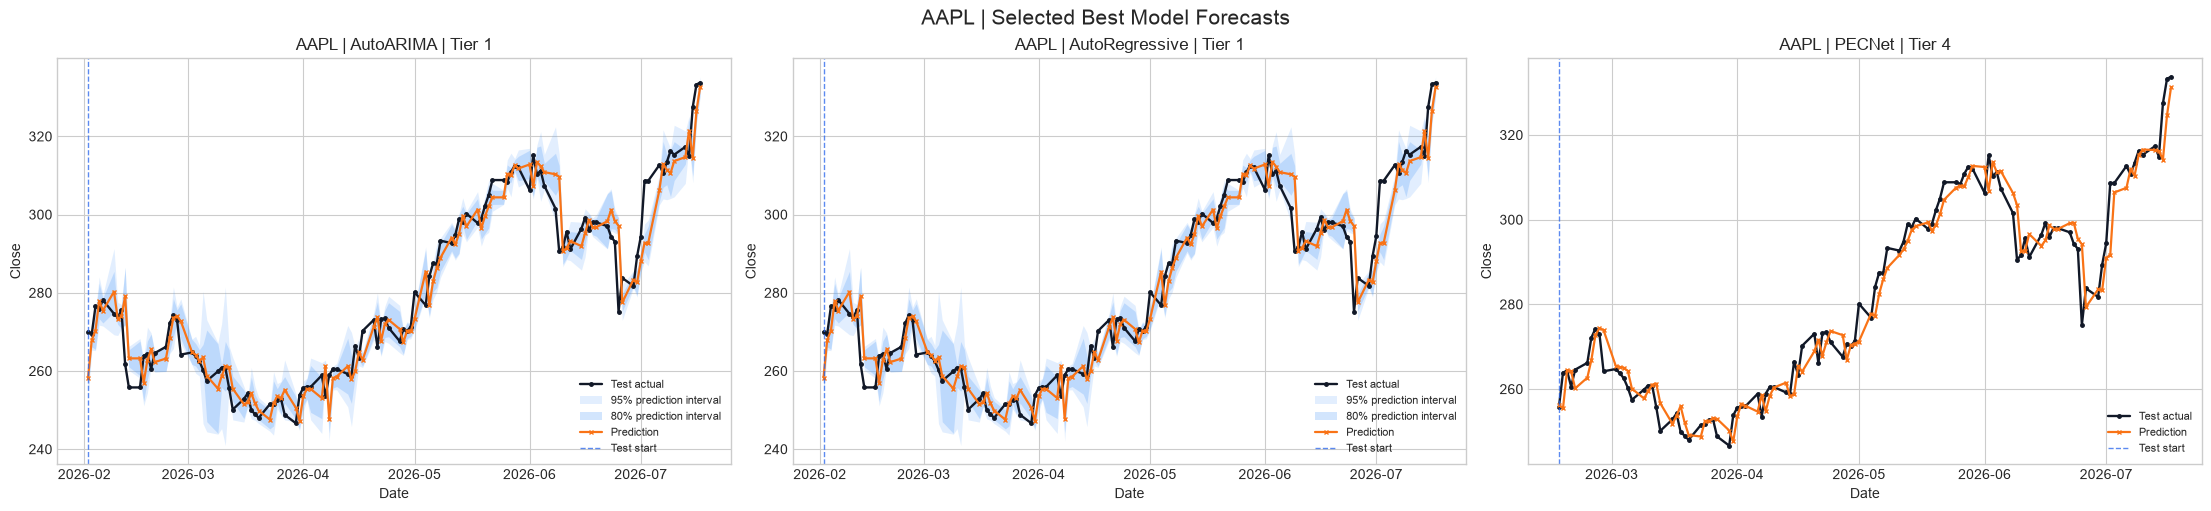

AAPL plot sources: ['mlflow_values', 'mlflow_values', 'mlflow_values']


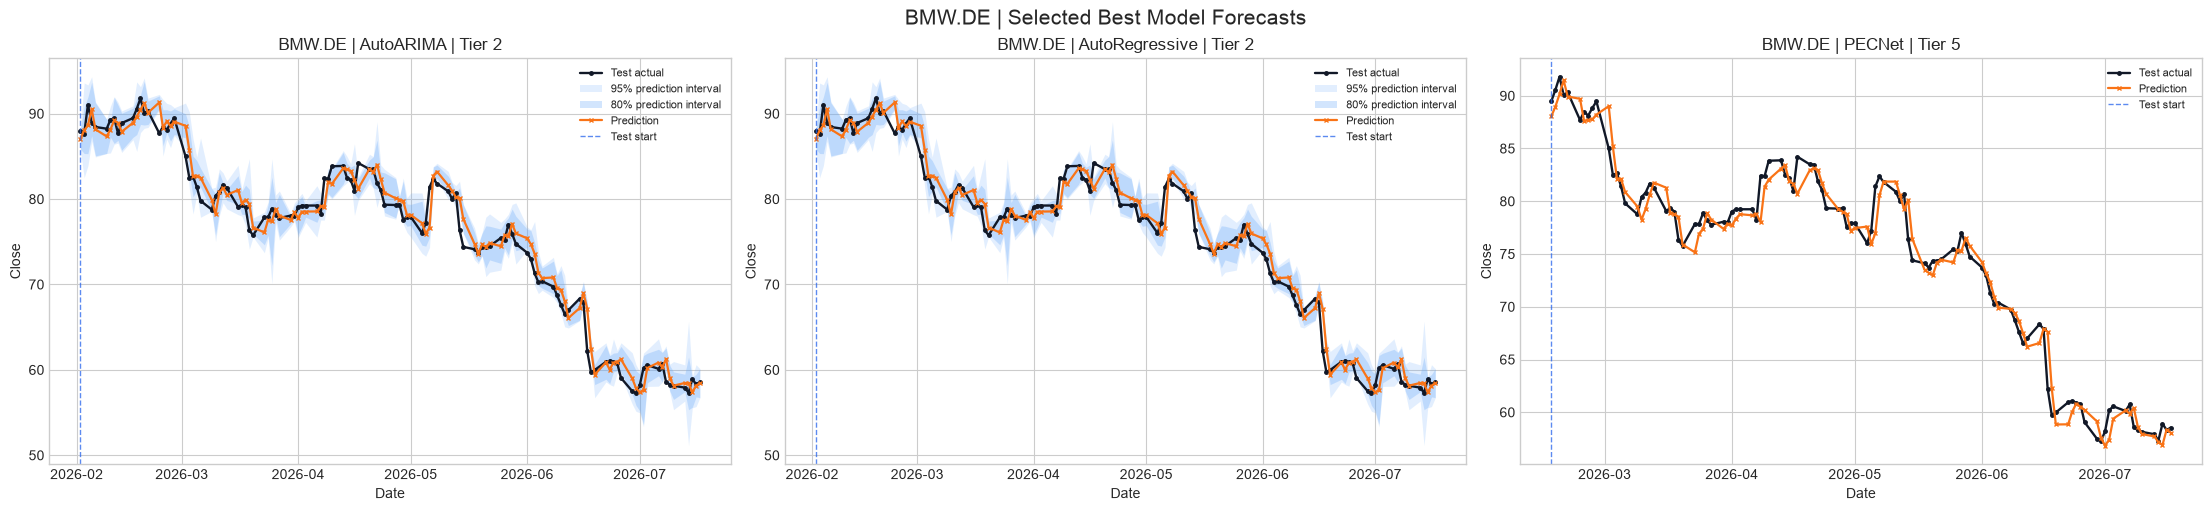

BMW.DE plot sources: ['mlflow_values', 'mlflow_values', 'mlflow_values']


In [17]:
for ticker in ["AAPL", "BMW.DE"]:
    ticker_results = [result for result in loaded_results if result["selection"]["ticker"] == ticker]
    fig, axes = plt.subplots(1, len(ticker_results), figsize=(22, 5), constrained_layout=True)
    if len(ticker_results) == 1:
        axes = [axes]
    plot_sources = []
    for ax, result in zip(axes, ticker_results):
        plot_sources.append(plot_selection(ax, result["selection"], result))
    fig.suptitle(f"{ticker} | Selected Best Model Forecasts", fontsize=15)
    plt.show()
    print(f"{ticker} plot sources: {plot_sources}")


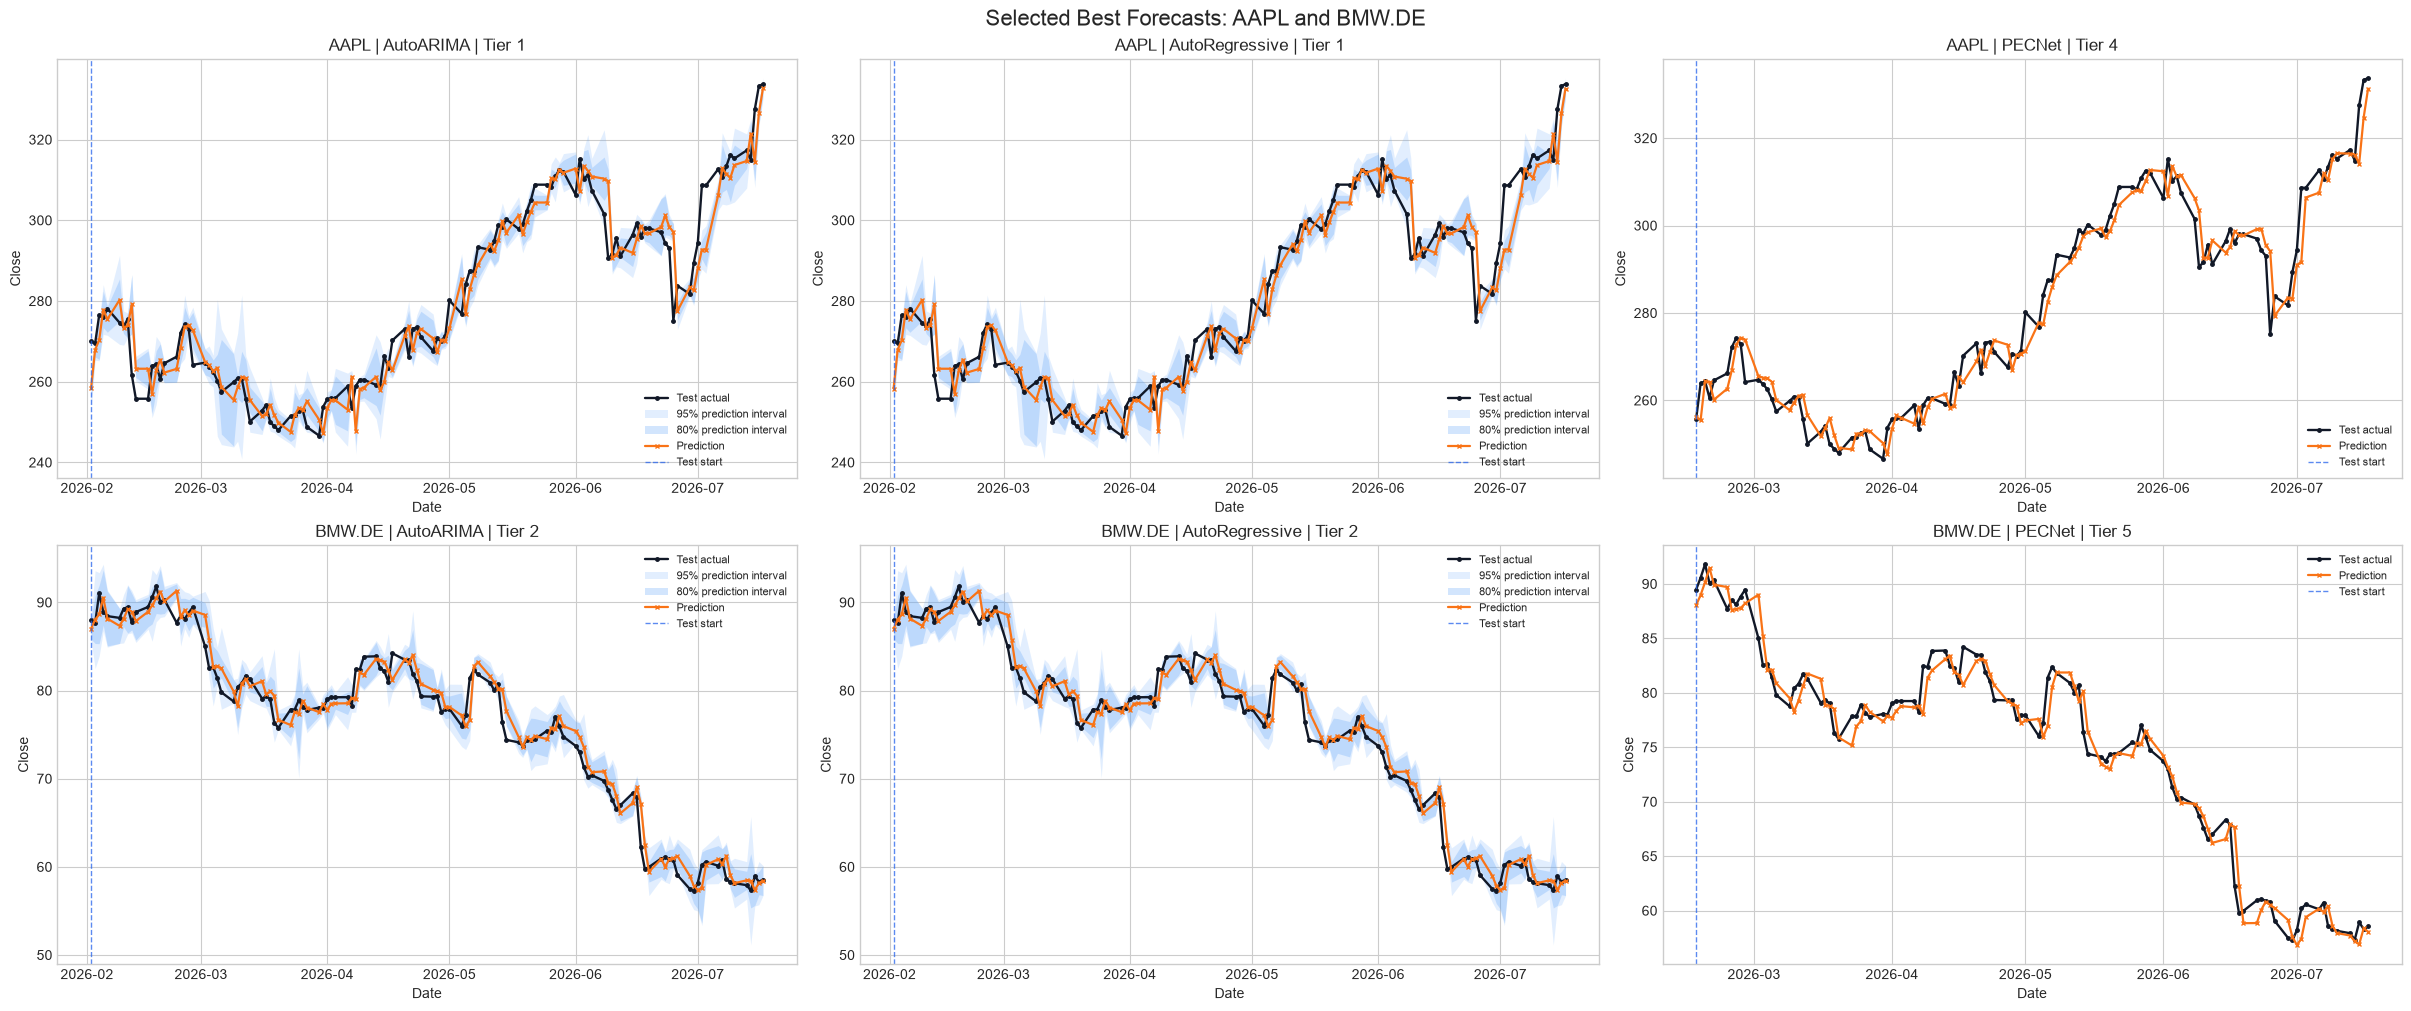

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(24, 10), constrained_layout=True)
for ax, result in zip(axes.ravel(), loaded_results):
    plot_selection(ax, result["selection"], result)
fig.suptitle("Selected Best Forecasts: AAPL and BMW.DE", fontsize=16)
plt.show()


# Ticker-Level Forecast Overlays

This section puts the selected best model forecasts on the same ticker-level plot.

For each ticker, it creates two versions:

1. Actual + forecasts + available confidence intervals
2. Actual + point forecasts only

PECNet is plotted as a point forecast because the current PECNet artifacts do not include prediction intervals.

In [19]:
MODEL_COLORS = {
    "AutoARIMA": "#2563eb",
    "AutoRegressive": "#7c3aed",
    "PECNet": "#f97316",
}


def selected_results_for_ticker(ticker: str) -> list[dict[str, Any]]:
    return [
        result for result in loaded_results
        if result["selection"]["ticker"] == ticker
        and not result.get("predictions", pd.DataFrame()).empty
    ]


def selected_model_label(selection: dict[str, str]) -> str:
    return f"{selection['tier']} | {selection['model']}"


def first_train_actual(results: list[dict[str, Any]]) -> pd.DataFrame:
    for result in results:
        train = result.get("train", pd.DataFrame()).copy()
        if not train.empty and {"ds", "y"}.issubset(train.columns):
            train["ds"] = pd.to_datetime(train["ds"], errors="coerce")
            return train.dropna(subset=["ds"]).sort_values("ds").tail(120)
    return pd.DataFrame()


def combined_test_actual(results: list[dict[str, Any]]) -> pd.DataFrame:
    actual_frames = []
    for result in results:
        predictions = result.get("predictions", pd.DataFrame()).copy()
        if not predictions.empty and {"ds", "y"}.issubset(predictions.columns):
            actual = predictions[["ds", "y"]].copy()
            actual["ds"] = pd.to_datetime(actual["ds"], errors="coerce")
            actual_frames.append(actual.dropna(subset=["ds"]))
    if not actual_frames:
        return pd.DataFrame()
    return (
        pd.concat(actual_frames, ignore_index=True)
        .drop_duplicates("ds", keep="first")
        .sort_values("ds")
        .reset_index(drop=True)
    )


def plot_selected_forecast_overlay(
    ax,
    *,
    ticker: str,
    results: list[dict[str, Any]],
    include_intervals: bool,
) -> None:
    train = first_train_actual(results)
    actual = combined_test_actual(results)

    if not train.empty:
        ax.plot(
            train["ds"],
            train["y"],
            color="#94a3b8",
            linewidth=1.25,
            label="Train actual (last 120)",
        )

    if not actual.empty:
        ax.plot(
            actual["ds"],
            actual["y"],
            color="#111827",
            linewidth=2.0,
            marker="o",
            markersize=2.8,
            label="Test actual",
        )
        ax.axvline(
            actual["ds"].min(),
            color="#2563eb",
            linestyle="--",
            linewidth=1.0,
            alpha=0.75,
            label="Test start",
        )

    for result in results:
        selection = result["selection"]
        model = selection["model"]
        predictions = result.get("predictions", pd.DataFrame()).copy()
        if predictions.empty or model not in predictions.columns or "ds" not in predictions.columns:
            continue

        predictions["ds"] = pd.to_datetime(predictions["ds"], errors="coerce")
        predictions = predictions.dropna(subset=["ds"]).sort_values("ds")
        color = MODEL_COLORS.get(model, "#0f766e")
        label = selected_model_label(selection)

        if include_intervals:
            for level, alpha in [(95, 0.09), (80, 0.14)]:
                lo_col, hi_col = interval_pair_columns(predictions, model, level)
                if lo_col and hi_col:
                    ax.fill_between(
                        predictions["ds"],
                        pd.to_numeric(predictions[lo_col], errors="coerce"),
                        pd.to_numeric(predictions[hi_col], errors="coerce"),
                        color=color,
                        alpha=alpha,
                        linewidth=0,
                        label=f"{label} {level}% interval",
                    )

        ax.plot(
            predictions["ds"],
            pd.to_numeric(predictions[model], errors="coerce"),
            color=color,
            linewidth=1.7,
            marker="x",
            markersize=3.2,
            label=f"{label} prediction",
        )

    interval_text = "with available intervals" if include_intervals else "point forecasts only"
    ax.set_title(f"{ticker} selected best forecasts ({interval_text})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Close")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=7)


def plot_ticker_overlay_versions(ticker: str) -> None:
    results = selected_results_for_ticker(ticker)
    if not results:
        print(f"No MLflow value tables loaded for {ticker}. Run MLflow or use the PNG fallback plots above.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(24, 6), constrained_layout=True)
    plot_selected_forecast_overlay(
        axes[0],
        ticker=ticker,
        results=results,
        include_intervals=True,
    )
    plot_selected_forecast_overlay(
        axes[1],
        ticker=ticker,
        results=results,
        include_intervals=False,
    )
    fig.suptitle(f"{ticker}: Best Model Forecast Overlay", fontsize=16)
    plt.show()


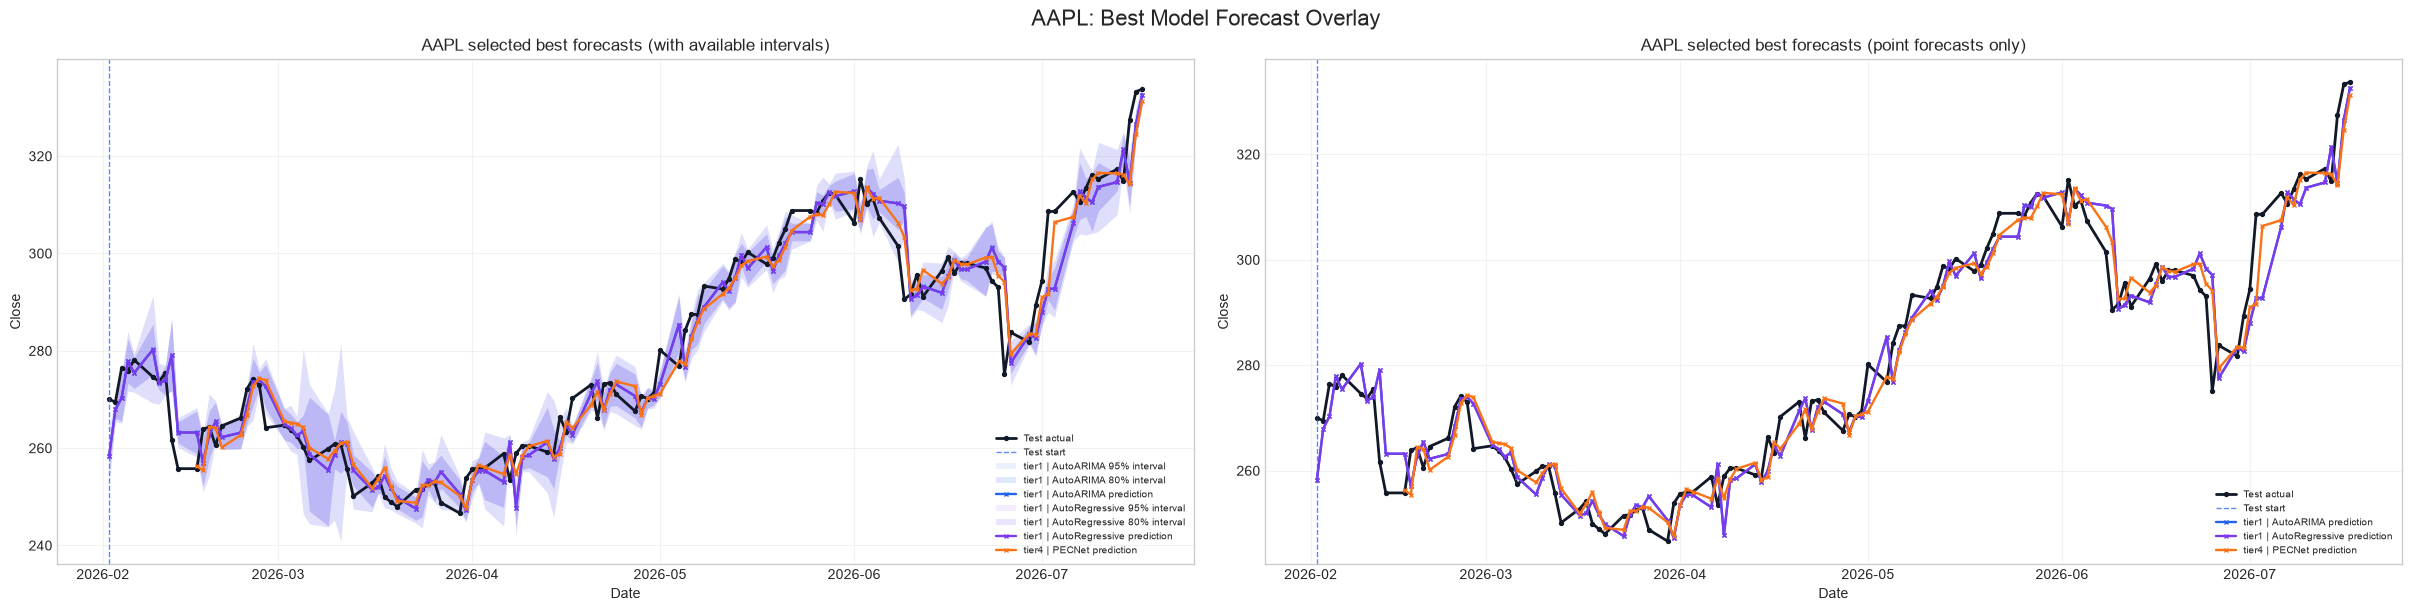

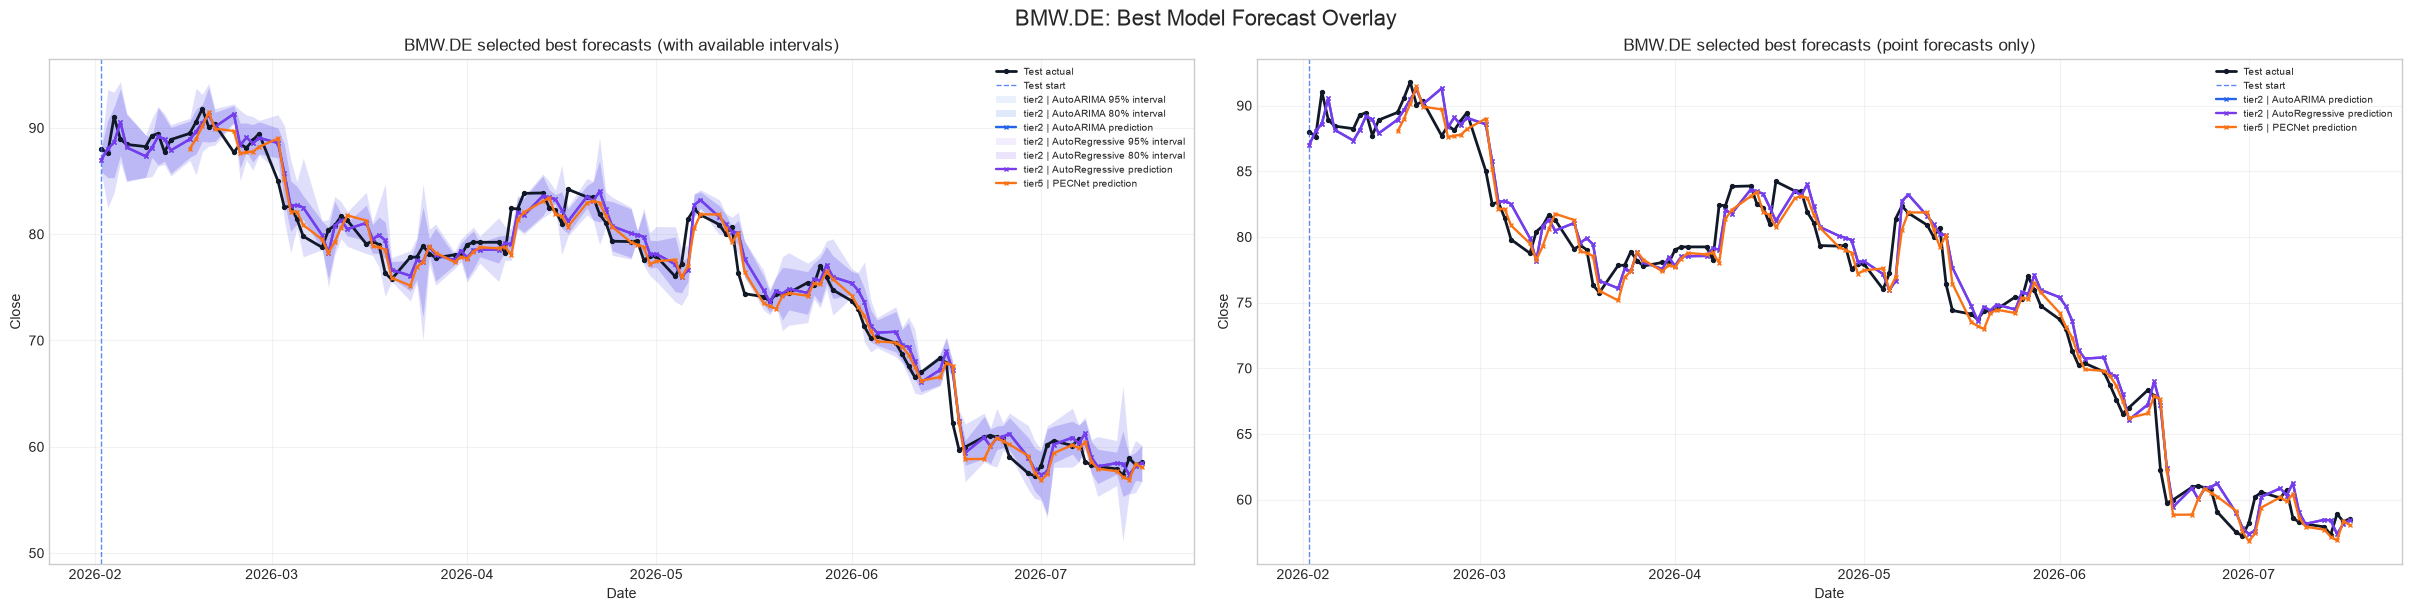

In [20]:
for ticker in ["AAPL", "BMW.DE"]:
    plot_ticker_overlay_versions(ticker)


# Regression Metric Analysis

This section loads all local `regression_metrics.csv` files from the artifact folder, enriches them with tier/family/source metadata, and creates ticker-based comparison plots plus Top 5 R² model views.

In [21]:
def parse_metric_source(path: Path) -> dict[str, str | None]:
    rel = path.relative_to(ARTIFACT_ROOT)
    parts = rel.parts
    family = next((part for part in parts if part in {"mlforecast", "statsforecast", "pecnet"}), None)
    tier = next((part for part in parts if re.fullmatch(r"tier\d+", part)), None)
    ticker = None
    if family == "pecnet" and "tickers" in parts:
        idx = parts.index("tickers")
        if idx + 1 < len(parts):
            ticker = parts[idx + 1]
    return {
        "_tier": tier,
        "_family": family,
        "_source_file": rel.as_posix(),
        "_source_ticker": ticker,
    }


def load_all_regression_metrics() -> pd.DataFrame:
    frames = []
    metric_files = sorted(ARTIFACT_ROOT.rglob("regression_metrics.csv"))
    for metric_file in metric_files:
        frame = pd.read_csv(metric_file)
        frame.columns = [str(column).strip() for column in frame.columns]
        metadata = parse_metric_source(metric_file)
        for key, value in metadata.items():
            frame.insert(0, key, value)
        frames.append(frame)
    if not frames:
        return pd.DataFrame()

    metrics = pd.concat(frames, ignore_index=True, sort=False)
    for column in ["mae", "rmse", "mape", "r2", "rows"]:
        if column in metrics.columns:
            metrics[column] = pd.to_numeric(metrics[column], errors="coerce")

    metrics["family_label"] = metrics["_family"].str.replace("forecast", "Forecast", regex=False).str.replace("pecnet", "PECNet", regex=False)
    metrics["model_key"] = (
        metrics["unique_id"].astype(str)
        + " | " + metrics["_tier"].astype(str)
        + " | " + metrics["_family"].astype(str)
        + " | " + metrics["model"].astype(str)
    )
    metrics["plot_label"] = (
        metrics["_tier"].astype(str)
        + " | " + metrics["_family"].astype(str)
        + " | " + metrics["model"].astype(str)
    )
    return metrics


regression_metrics = load_all_regression_metrics()
print(f"Loaded regression metric rows: {len(regression_metrics)}")
display(
    regression_metrics
    .sort_values(["unique_id", "r2", "rmse"], ascending=[True, False, True])
    [["_tier", "_family", "unique_id", "model", "mae", "rmse", "mape", "r2", "rows", "_source_file"]]
)


Loaded regression metric rows: 66


,_tier,_family,unique_id,model,mae,rmse,mape,r2,rows,_source_file
36,tier4,pecnet,AAPL,PECNet,3.470117,4.771307,1.230543,0.956881,110,pecnet/tier4/tickers/AAPL/metrics/regression_m...
30,tier1,pecnet,AAPL,PECNet,4.230290,5.587108,1.486679,0.940875,110,pecnet/tier1/tickers/AAPL/metrics/regression_m...
34,tier3,pecnet,AAPL,PECNet,4.398178,5.654628,1.539269,0.939437,110,pecnet/tier3/tickers/AAPL/metrics/regression_m...
42,tier1,statsforecast,AAPL,AutoARIMA,4.215522,5.792026,1.500934,0.932383,120,statsforecast/tier1/metrics/regression_metrics...
45,tier1,statsforecast,AAPL,AutoRegressive,4.216641,5.792673,1.501281,0.932367,120,statsforecast/tier1/metrics/regression_metrics...
...,...,...,...,...,...,...,...,...,...,...
56,tier2,statsforecast,BMW.DE,AutoTheta,12.400969,15.606846,18.401391,-1.508291,120,statsforecast/tier2/metrics/regression_metrics...
64,tier3,statsforecast,BMW.DE,AutoTheta,12.400969,15.606846,18.401391,-1.508291,120,statsforecast/tier3/metrics/regression_metrics...
47,tier1,statsforecast,BMW.DE,AutoETS,13.215954,16.562217,19.587489,-1.824780,120,statsforecast/tier1/metrics/regression_metrics...
55,tier2,statsforecast,BMW.DE,AutoETS,13.215954,16.562217,19.587489,-1.824780,120,statsforecast/tier2/metrics/regression_metrics...


,_tier,_family,unique_id,model,mae,rmse,mape,r2,rows
0,tier2,statsforecast,BMW.DE,AutoARIMA,1.161286,1.538179,1.549745,0.975635,120
1,tier2,statsforecast,BMW.DE,AutoRegressive,1.161286,1.538179,1.549745,0.975635,120
2,tier3,statsforecast,BMW.DE,AutoARIMA,1.161286,1.538179,1.549745,0.975635,120
3,tier3,statsforecast,BMW.DE,AutoRegressive,1.161286,1.538179,1.549745,0.975635,120
4,tier1,statsforecast,BMW.DE,AutoARIMA,1.160738,1.542910,1.549047,0.975485,120


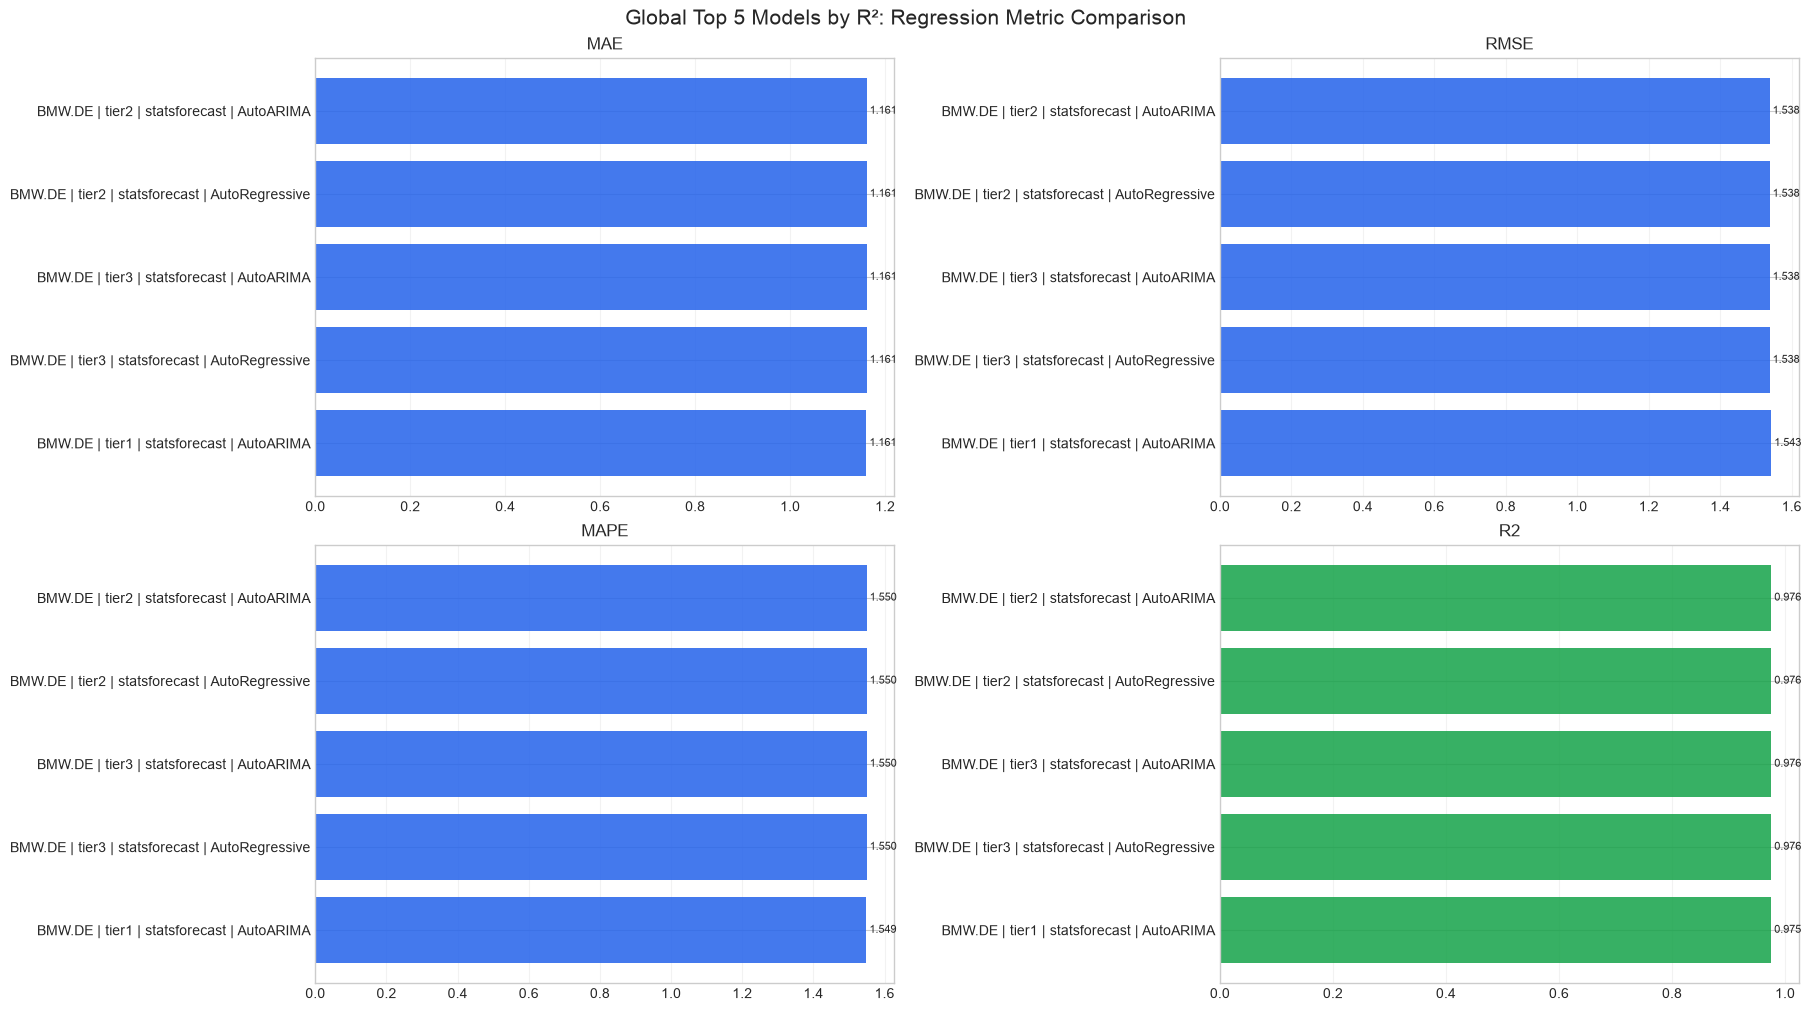

In [22]:
def plot_metric_bars(
    frame: pd.DataFrame,
    *,
    title: str,
    label_column: str = "plot_label",
) -> None:
    if frame.empty:
        print(f"No data for {title}")
        return

    metrics_to_plot = ["mae", "rmse", "mape", "r2"]
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()
    labels = frame[label_column].astype(str).tolist()

    for ax, metric in zip(axes, metrics_to_plot):
        values = frame[metric].astype(float)
        colors = ["#16a34a" if metric == "r2" else "#2563eb" for _ in values]
        ax.barh(labels, values, color=colors, alpha=0.86)
        ax.set_title(metric.upper())
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.25)
        for index, value in enumerate(values):
            ax.text(value, index, f" {value:.3f}", va="center", fontsize=8)

    fig.suptitle(title, fontsize=15)
    plt.show()


def top_by_r2(frame: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    return (
        frame.dropna(subset=["r2"])
        .sort_values(["r2", "rmse", "mae"], ascending=[False, True, True])
        .head(n)
        .reset_index(drop=True)
    )


global_top5_by_r2 = top_by_r2(regression_metrics, 5)
display(global_top5_by_r2[["_tier", "_family", "unique_id", "model", "mae", "rmse", "mape", "r2", "rows"]])
plot_metric_bars(
    global_top5_by_r2,
    title="Global Top 5 Models by R²: Regression Metric Comparison",
    label_column="model_key",
)


,_tier,_family,unique_id,model,mae,rmse,mape,r2,rows
0,tier4,pecnet,AAPL,PECNet,3.470117,4.771307,1.230543,0.956881,110
1,tier1,pecnet,AAPL,PECNet,4.230290,5.587108,1.486679,0.940875,110
2,tier3,pecnet,AAPL,PECNet,4.398178,5.654628,1.539269,0.939437,110
3,tier1,statsforecast,AAPL,AutoARIMA,4.215522,5.792026,1.500934,0.932383,120
4,tier1,statsforecast,AAPL,AutoRegressive,4.216641,5.792673,1.501281,0.932367,120


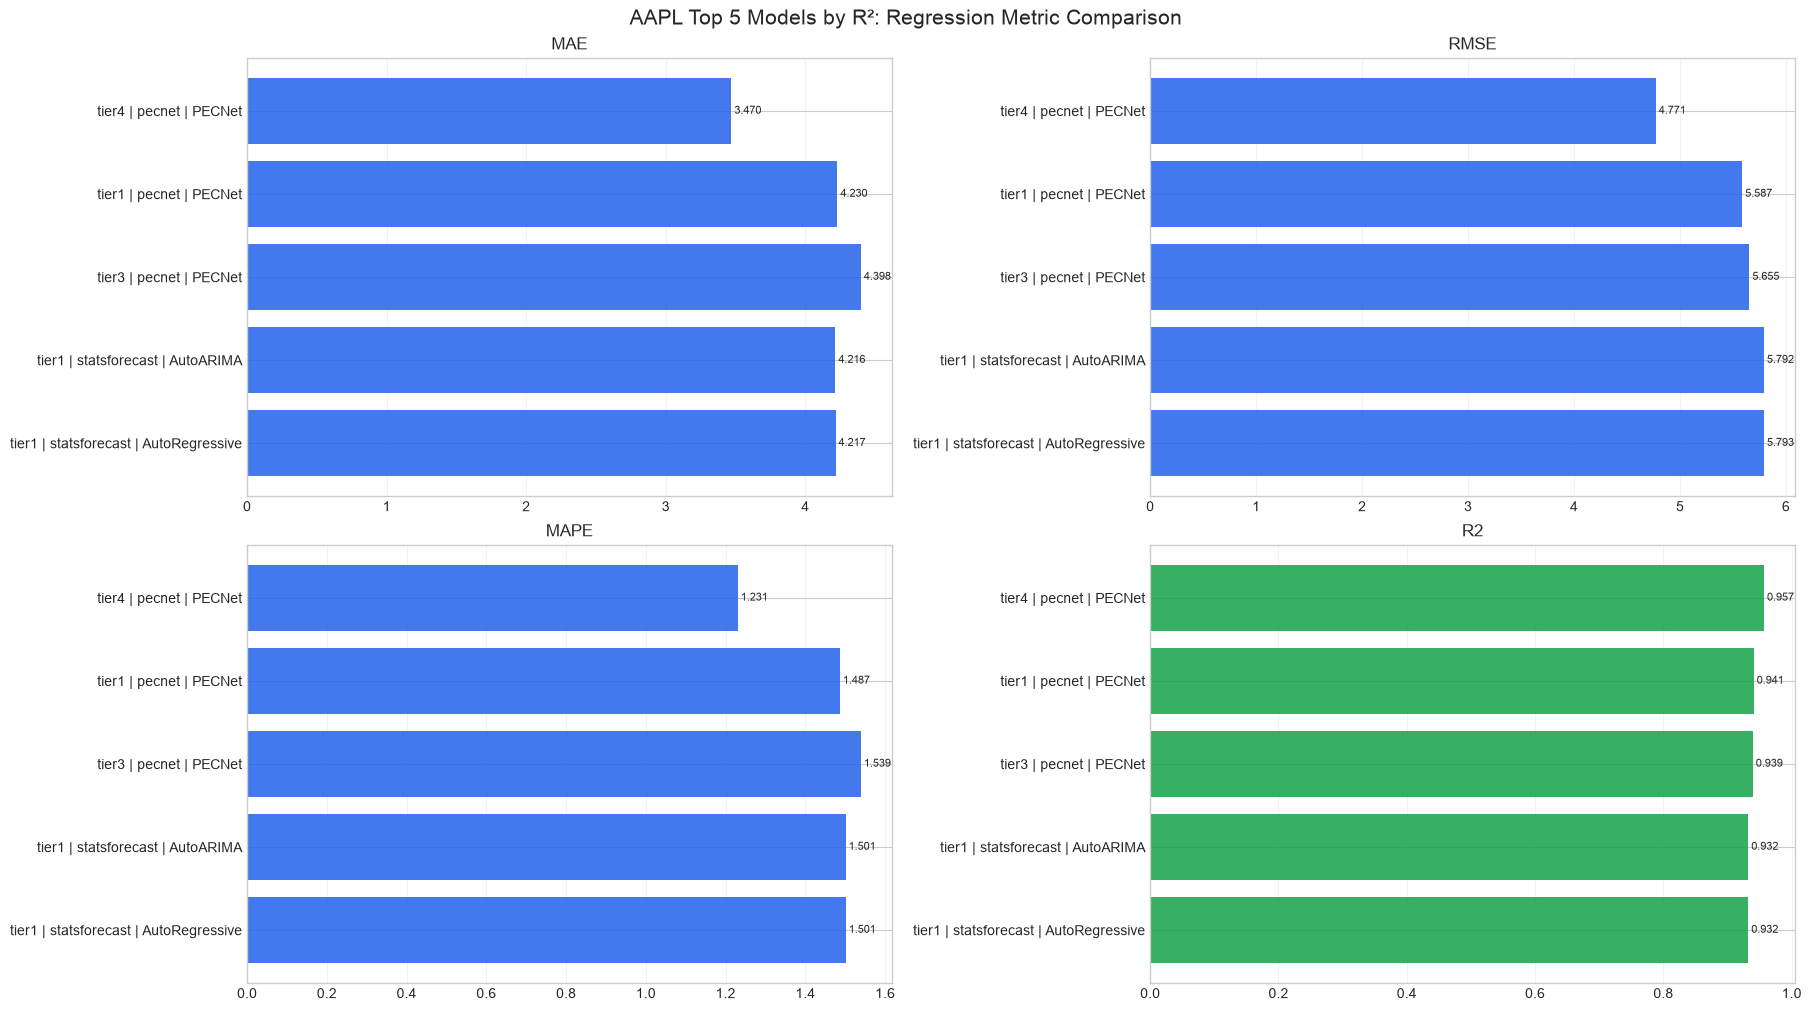

,_tier,_family,unique_id,model,mae,rmse,mape,r2,rows
0,tier2,statsforecast,BMW.DE,AutoARIMA,1.161286,1.538179,1.549745,0.975635,120
1,tier2,statsforecast,BMW.DE,AutoRegressive,1.161286,1.538179,1.549745,0.975635,120
2,tier3,statsforecast,BMW.DE,AutoARIMA,1.161286,1.538179,1.549745,0.975635,120
3,tier3,statsforecast,BMW.DE,AutoRegressive,1.161286,1.538179,1.549745,0.975635,120
4,tier1,statsforecast,BMW.DE,AutoARIMA,1.160738,1.542910,1.549047,0.975485,120


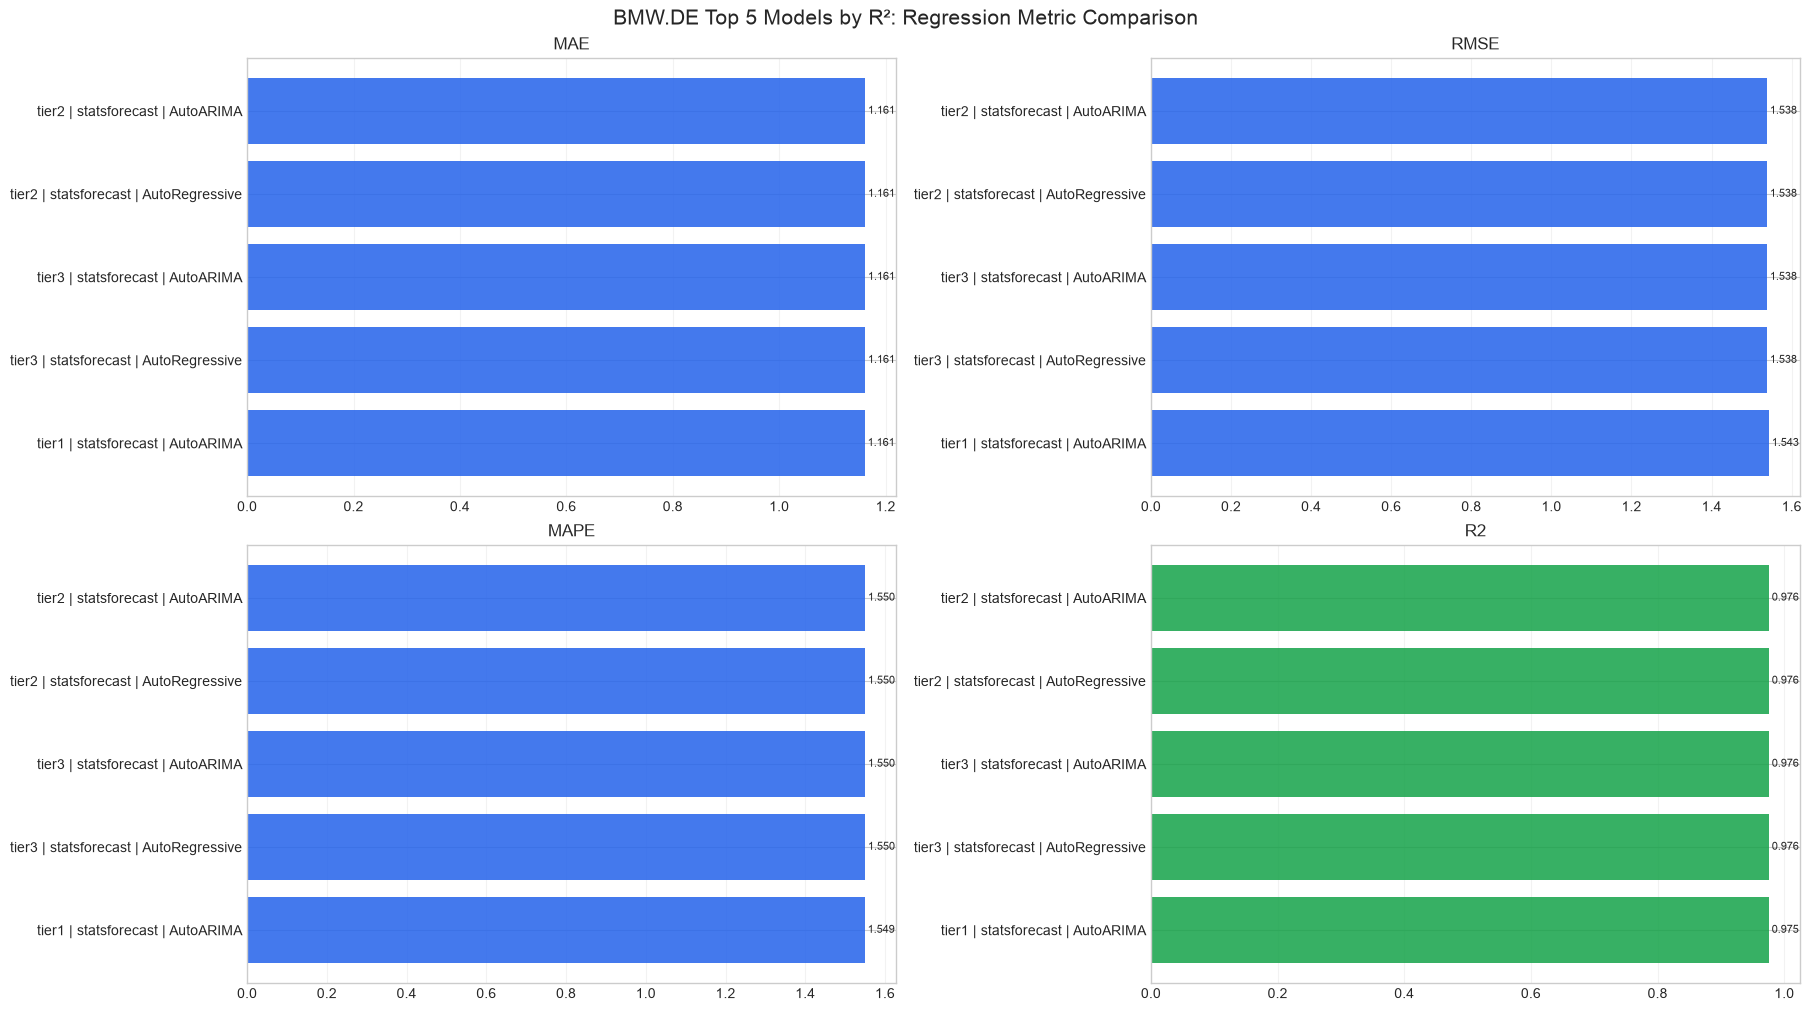

In [23]:
for ticker, ticker_frame in regression_metrics.groupby("unique_id", observed=True):
    ticker_top5 = top_by_r2(ticker_frame, 5)
    display(ticker_top5[["_tier", "_family", "unique_id", "model", "mae", "rmse", "mape", "r2", "rows"]])
    plot_metric_bars(
        ticker_top5,
        title=f"{ticker} Top 5 Models by R²: Regression Metric Comparison",
        label_column="plot_label",
    )


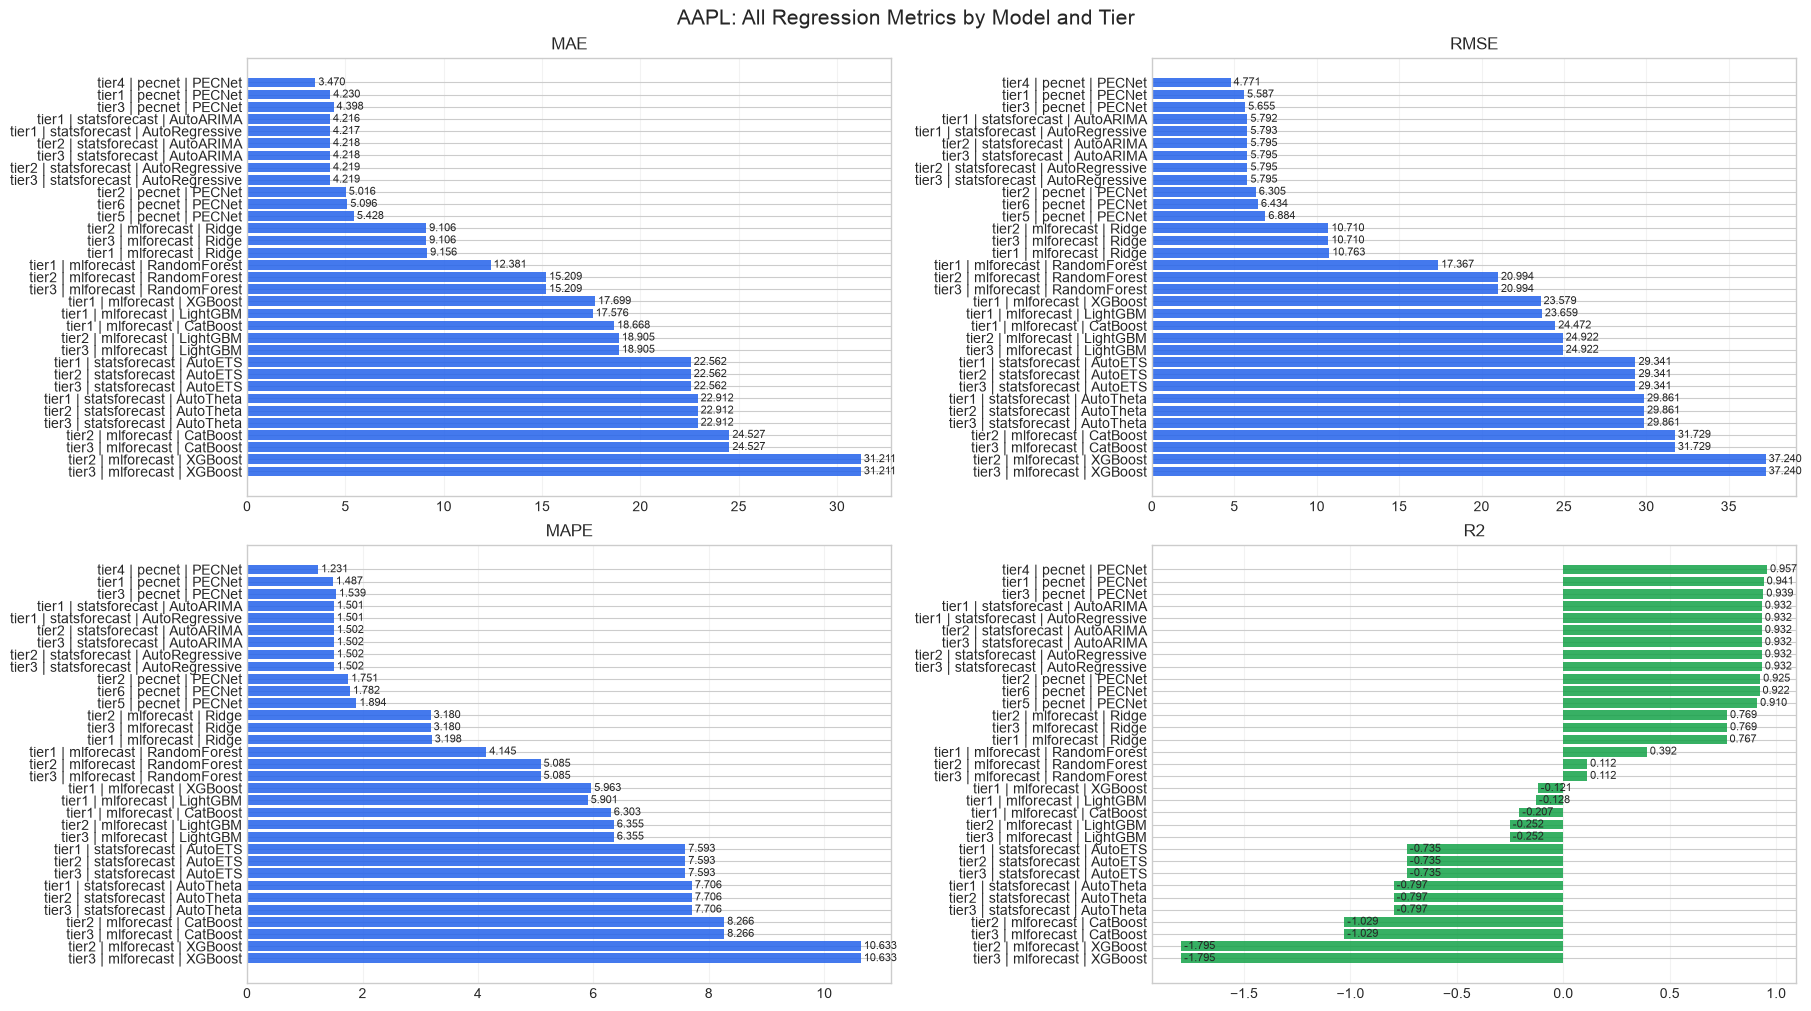

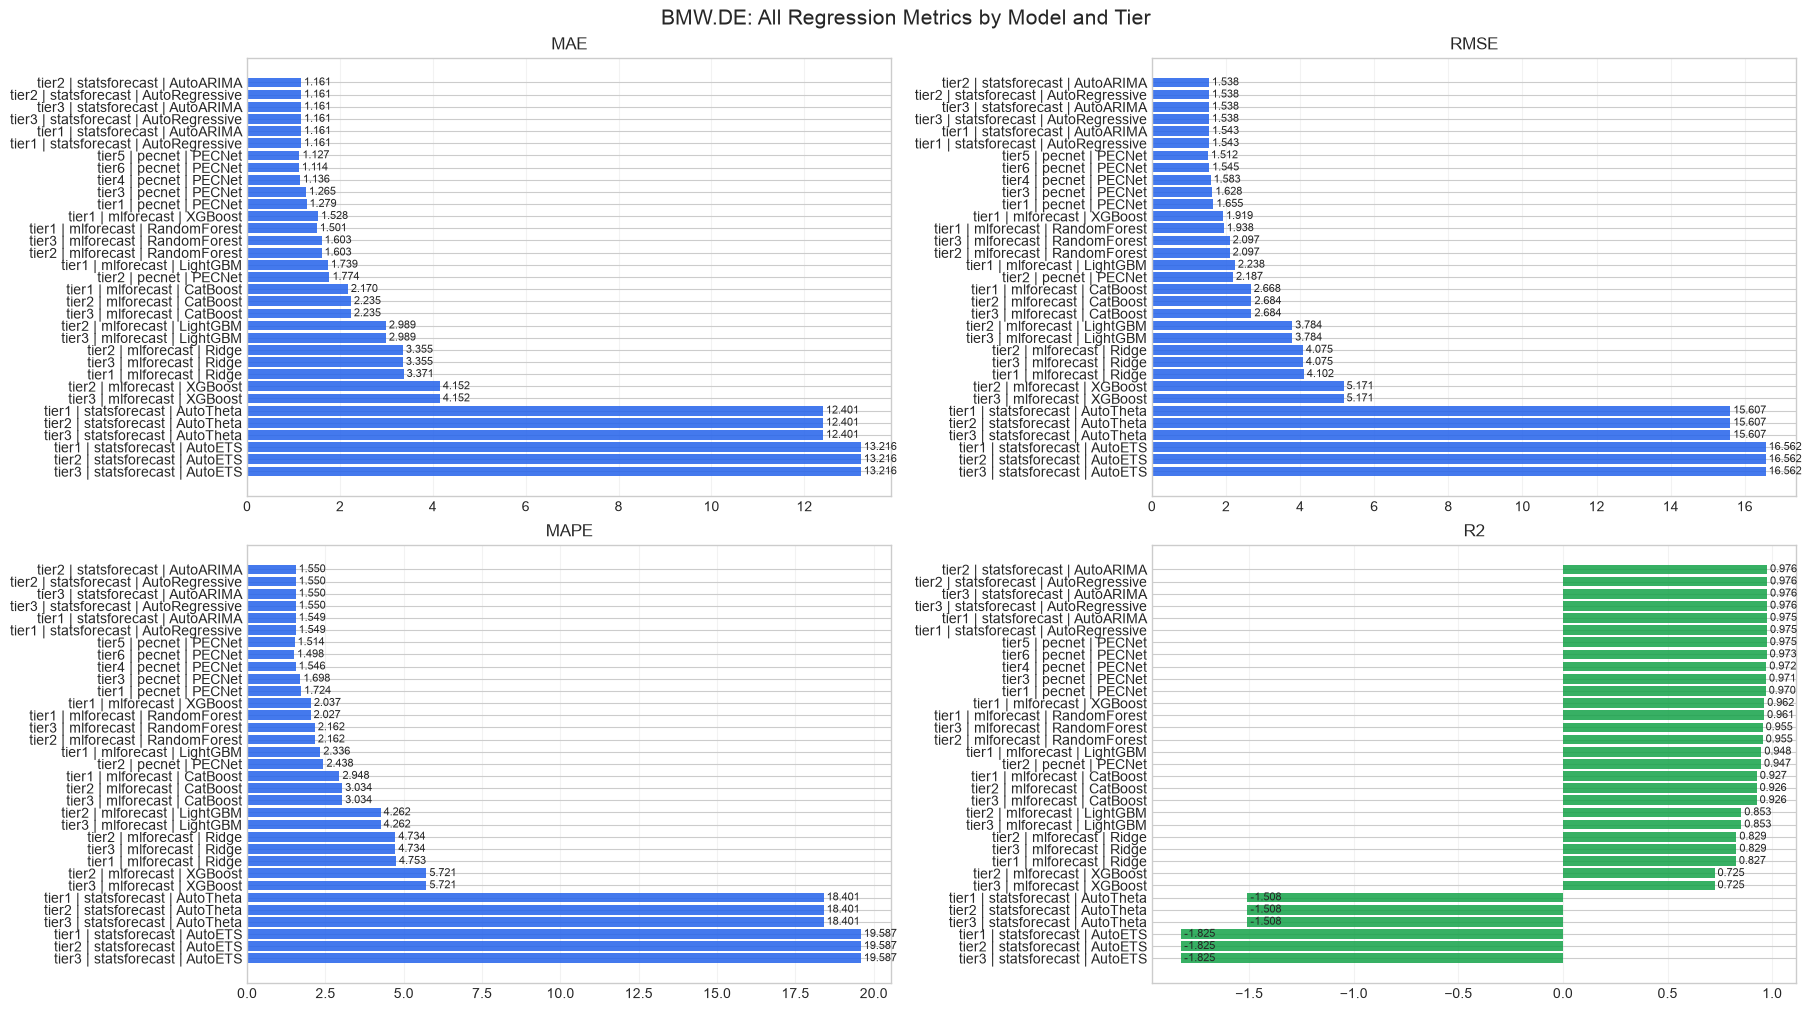

In [24]:
def plot_ticker_metric_matrix(metrics: pd.DataFrame) -> None:
    for ticker, ticker_frame in metrics.groupby("unique_id", observed=True):
        ordered = ticker_frame.sort_values(["r2", "rmse"], ascending=[False, True]).reset_index(drop=True)
        plot_metric_bars(
            ordered,
            title=f"{ticker}: All Regression Metrics by Model and Tier",
            label_column="plot_label",
        )


plot_ticker_metric_matrix(regression_metrics)


# Conventional Gap Trading Baseline Plots

This section reads the rule-based conventional gap trading output from TimescaleDB and creates paper-ready plots for the baseline strategy. The plots are filtered to the out-of-sample period from 2025-01-01 to the latest available observation, matching the model-evaluation visualization window.


In [ ]:
import numpy as np
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

GAP_OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "paper_gap_trading_plots"
GAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GAP_TEST_START = pd.Timestamp("2025-01-01")
GAP_TEST_END = pd.Timestamp.today(tz="Europe/Istanbul").tz_localize(None).normalize()
GAP_TICKERS = ["AAPL", "BMW.DE"]
GAP_FILL_LOOKAHEAD_BARS = 10
GAP_CANDLE_TAIL_BARS = 180

GAP_TYPE_ORDER = [
    "Common Up",
    "Common Down",
    "Breakaway Up",
    "Breakaway Down",
    "Runaway Up",
    "Runaway Down",
    "Exhaustion Up",
    "Exhaustion Down",
]

GAP_TYPE_STYLES = {
    "Common Up": {"color": "#dc2626", "marker": "v", "label": "Common Up / short-to-fill"},
    "Common Down": {"color": "#16a34a", "marker": "^", "label": "Common Down / long-to-fill"},
    "Breakaway Up": {"color": "#0891b2", "marker": "^", "label": "Breakaway Up"},
    "Breakaway Down": {"color": "#9333ea", "marker": "v", "label": "Breakaway Down"},
    "Runaway Up": {"color": "#2563eb", "marker": "P", "label": "Runaway Up"},
    "Runaway Down": {"color": "#f97316", "marker": "X", "label": "Runaway Down"},
    "Exhaustion Up": {"color": "#be123c", "marker": "s", "label": "Exhaustion Up"},
    "Exhaustion Down": {"color": "#15803d", "marker": "s", "label": "Exhaustion Down"},
}

print("Gap plot output:", GAP_OUTPUT_DIR)
print("Gap plot window:", GAP_TEST_START.date(), "to", GAP_TEST_END.date())


In [ ]:
def normalize_gap_frame(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame

    frame = frame.copy()
    frame.columns = [str(column).strip() for column in frame.columns]

    if "date" in frame.columns:
        frame["date"] = pd.to_datetime(frame["date"], errors="coerce", utc=True).dt.tz_localize(None)

    if "symbol" in frame.columns:
        frame["symbol"] = frame["symbol"].astype(str)

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "target_close",
        "RSI",
        "SMA_Short",
        "SMA_Long",
        "Vol_SMA",
        "Range_high",
        "Range_low",
        "ADX",
    ]
    for column in numeric_columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")

    if "Gap_Type" in frame.columns:
        frame["Gap_Type"] = frame["Gap_Type"].fillna("None").astype(str)

    return frame.dropna(subset=["symbol", "date"]).sort_values(["symbol", "date"]).reset_index(drop=True)


def load_conventional_gap_trading_from_timescale(
    tickers: list[str] | None = None,
    start: pd.Timestamp | str | None = None,
    end: pd.Timestamp | str | None = None,
) -> pd.DataFrame:
    try:
        from sqlalchemy import bindparam, create_engine, text
    except Exception as exc:
        print(f"SQLAlchemy unavailable, cannot load conventional gap table: {exc!r}")
        return pd.DataFrame()

    config = {
        "host": os.getenv("TIMESCALE_HOST", "127.0.0.1"),
        "port": int(os.getenv("TIMESCALE_PORT", "5432")),
        "dbname": os.getenv("TIMESCALE_DB", "dataops"),
        "user": os.getenv("TIMESCALE_USER", "dataops"),
        "password": os.getenv("TIMESCALE_PASSWORD", "dataops"),
    }

    where_parts = []
    params: dict[str, object] = {}

    if start is not None:
        where_parts.append('"date" >= :start')
        params["start"] = pd.Timestamp(start).to_pydatetime()

    if end is not None:
        where_parts.append('"date" <= :end')
        params["end"] = pd.Timestamp(end).to_pydatetime()

    if tickers:
        where_parts.append("symbol IN :tickers")
        params["tickers"] = list(tickers)

    where_sql = "WHERE " + " AND ".join(where_parts) if where_parts else ""
    sql = text(
        "SELECT * "
        "FROM feature_store.conventional_gap_trading "
        f"{where_sql} "
        'ORDER BY symbol, "date";'
    )

    if tickers:
        sql = sql.bindparams(bindparam("tickers", expanding=True))

    url = (
        f"postgresql+psycopg2://{config['user']}:{config['password']}"
        f"@{config['host']}:{config['port']}/{config['dbname']}"
    )

    try:
        engine = create_engine(url)
        frame = pd.read_sql_query(sql, engine, params=params)
    except Exception as exc:
        print(f"Could not read feature_store.conventional_gap_trading from TimescaleDB: {exc}")
        return pd.DataFrame()

    frame = normalize_gap_frame(frame)
    print(
        "Loaded conventional gap rows:",
        len(frame),
        "| symbols:",
        sorted(frame["symbol"].unique()) if not frame.empty and "symbol" in frame else [],
    )
    return frame


def add_common_gap_fill_analysis(frame: pd.DataFrame, lookahead_bars: int = 10) -> pd.DataFrame:
    if frame.empty:
        return frame

    output_frames = []
    for symbol, symbol_frame in frame.groupby("symbol", observed=True):
        symbol_frame = symbol_frame.sort_values("date").reset_index(drop=True).copy()
        symbol_frame["prev_high"] = symbol_frame["high"].shift(1)
        symbol_frame["prev_low"] = symbol_frame["low"].shift(1)
        symbol_frame["common_fill_target"] = np.nan
        symbol_frame["common_fill_date"] = pd.NaT
        symbol_frame["common_fill_bars"] = np.nan
        symbol_frame["common_filled"] = False
        symbol_frame["common_fill_direction"] = None

        for index, row in symbol_frame.iterrows():
            gap_type = row.get("Gap_Type", "None")
            if gap_type not in {"Common Up", "Common Down"}:
                continue

            if gap_type == "Common Up":
                target = row.get("prev_high")
                direction = "short_to_previous_high"
                future = symbol_frame.iloc[index : index + lookahead_bars + 1]
                hits = future[future["low"] <= target]
            else:
                target = row.get("prev_low")
                direction = "long_to_previous_low"
                future = symbol_frame.iloc[index : index + lookahead_bars + 1]
                hits = future[future["high"] >= target]

            if pd.isna(target):
                continue

            symbol_frame.loc[index, "common_fill_target"] = float(target)
            symbol_frame.loc[index, "common_fill_direction"] = direction

            if not hits.empty:
                hit_index = int(hits.index[0])
                symbol_frame.loc[index, "common_filled"] = True
                symbol_frame.loc[index, "common_fill_date"] = symbol_frame.loc[hit_index, "date"]
                symbol_frame.loc[index, "common_fill_bars"] = hit_index - index

        output_frames.append(symbol_frame)

    return pd.concat(output_frames, ignore_index=True).sort_values(["symbol", "date"]).reset_index(drop=True)


In [ ]:
def gap_events(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty or "Gap_Type" not in frame.columns:
        return pd.DataFrame()
    return frame[frame["Gap_Type"].isin(GAP_TYPE_ORDER)].copy()


def plot_gap_type_distribution(frame: pd.DataFrame) -> None:
    events = gap_events(frame)
    if events.empty:
        print("No gap events found for distribution plot.")
        return

    counts = (
        events.groupby(["symbol", "Gap_Type"], observed=True)
        .size()
        .rename("count")
        .reset_index()
    )
    counts["Gap_Type"] = pd.Categorical(counts["Gap_Type"], categories=GAP_TYPE_ORDER, ordered=True)
    counts = counts.sort_values(["symbol", "Gap_Type"])

    pivot = counts.pivot_table(index="Gap_Type", columns="symbol", values="count", fill_value=0, observed=True)
    ax = pivot.plot(kind="bar", figsize=(14, 5), width=0.82, color=["#2563eb", "#f97316", "#16a34a", "#9333ea"])
    ax.set_title("Conventional Gap Trading: Signal Distribution", fontsize=14)
    ax.set_xlabel("Gap type")
    ax.set_ylabel("Signal count")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Ticker", frameon=True)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    path = GAP_OUTPUT_DIR / "conventional_gap_signal_distribution.png"
    ax.figure.savefig(path, dpi=240, bbox_inches="tight")
    print(f"Saved: {path}")
    display(counts)
    plt.show()


def common_gap_fill_summary(frame: pd.DataFrame) -> pd.DataFrame:
    events = frame[frame["Gap_Type"].isin(["Common Up", "Common Down"])].copy()
    if events.empty:
        return pd.DataFrame()

    summary = (
        events.groupby(["symbol", "Gap_Type"], observed=True)
        .agg(
            signals=("Gap_Type", "size"),
            filled=("common_filled", "sum"),
            median_fill_bars=("common_fill_bars", "median"),
            mean_fill_bars=("common_fill_bars", "mean"),
        )
        .reset_index()
    )
    summary["fill_rate"] = summary["filled"] / summary["signals"]
    return summary.sort_values(["symbol", "Gap_Type"]).reset_index(drop=True)


def plot_common_gap_fill_rate(frame: pd.DataFrame) -> None:
    summary = common_gap_fill_summary(frame)
    if summary.empty:
        print("No common gap events found for fill-rate plot.")
        return

    labels = summary["symbol"] + " | " + summary["Gap_Type"]
    fig, ax = plt.subplots(figsize=(12, 4.8))
    colors = [GAP_TYPE_STYLES.get(gap_type, {}).get("color", "#64748b") for gap_type in summary["Gap_Type"]]
    bars = ax.barh(labels, summary["fill_rate"], color=colors, alpha=0.88)
    ax.set_title(f"Common Gap Fill Rate within {GAP_FILL_LOOKAHEAD_BARS} Bars", fontsize=14)
    ax.set_xlabel("Fill rate")
    ax.set_xlim(0, 1)
    ax.grid(axis="x", alpha=0.25)
    ax.invert_yaxis()

    for bar, row in zip(bars, summary.to_dict("records")):
        ax.text(
            bar.get_width() + 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{row['fill_rate']:.1%} ({int(row['filled'])}/{int(row['signals'])})",
            va="center",
            fontsize=9,
        )

    plt.tight_layout()
    path = GAP_OUTPUT_DIR / "common_gap_fill_rate.png"
    fig.savefig(path, dpi=240, bbox_inches="tight")
    print(f"Saved: {path}")
    display(summary)
    plt.show()


def draw_candles(ax, frame: pd.DataFrame, width: float = 0.65) -> None:
    candle_frame = frame.dropna(subset=["date", "open", "high", "low", "close"]).copy()
    if candle_frame.empty:
        return

    xs = mdates.date2num(candle_frame["date"])
    for x_value, (_, row) in zip(xs, candle_frame.iterrows()):
        color = "#16a34a" if row["close"] >= row["open"] else "#dc2626"
        ax.vlines(x_value, row["low"], row["high"], color=color, linewidth=1.0, alpha=0.85)
        lower = min(row["open"], row["close"])
        height = abs(row["close"] - row["open"])
        if height == 0:
            height = max(row["high"] - row["low"], 1e-9) * 0.015
        rect = Rectangle(
            (x_value - width / 2, lower),
            width,
            height,
            facecolor=color,
            edgecolor=color,
            alpha=0.45,
            linewidth=0.8,
        )
        ax.add_patch(rect)

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))


def plot_gap_signal_candles(frame: pd.DataFrame, ticker: str, tail_bars: int = GAP_CANDLE_TAIL_BARS) -> None:
    ticker_frame = frame[frame["symbol"].eq(ticker)].sort_values("date").tail(tail_bars).copy()
    if ticker_frame.empty:
        print(f"No conventional gap rows found for {ticker}.")
        return

    fig, ax = plt.subplots(figsize=(18, 6))
    draw_candles(ax, ticker_frame)

    plotted_labels = set()
    events = gap_events(ticker_frame)
    for gap_type in GAP_TYPE_ORDER:
        subset = events[events["Gap_Type"].eq(gap_type)].copy()
        if subset.empty:
            continue

        style = GAP_TYPE_STYLES[gap_type]
        y_values = np.where(gap_type.endswith("Up"), subset["high"] * 1.006, subset["low"] * 0.994)
        label = style["label"] if gap_type not in plotted_labels else None
        ax.scatter(
            subset["date"],
            y_values,
            s=72,
            marker=style["marker"],
            color=style["color"],
            edgecolor="white",
            linewidth=0.55,
            alpha=0.95,
            label=label,
            zorder=5,
        )
        plotted_labels.add(gap_type)

    common_events = events[events["Gap_Type"].isin(["Common Up", "Common Down"])].copy()
    target_label_drawn = False
    for _, row in common_events.dropna(subset=["common_fill_target"]).iterrows():
        start_date = row["date"]
        end_date = row["common_fill_date"] if pd.notna(row["common_fill_date"]) else start_date + pd.Timedelta(days=GAP_FILL_LOOKAHEAD_BARS * 2)
        color = GAP_TYPE_STYLES[row["Gap_Type"]]["color"]
        ax.hlines(
            row["common_fill_target"],
            xmin=start_date,
            xmax=end_date,
            colors=color,
            linestyles="--",
            linewidth=1.4,
            alpha=0.78,
            label="Common gap fill target" if not target_label_drawn else None,
        )
        target_label_drawn = True

        if bool(row.get("common_filled", False)) and pd.notna(row["common_fill_date"]):
            ax.scatter(
                row["common_fill_date"],
                row["common_fill_target"],
                s=58,
                marker="o",
                color=color,
                edgecolor="white",
                linewidth=0.6,
                zorder=6,
                label="Common gap fill" if "common_gap_fill" not in plotted_labels else None,
            )
            plotted_labels.add("common_gap_fill")

    ax.set_title(f"{ticker}: Conventional Gap Signals and Common Gap Fill Targets", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.18)
    ax.legend(loc="best", fontsize=8, frameon=True)
    fig.autofmt_xdate()
    plt.tight_layout()

    path = GAP_OUTPUT_DIR / f"{safe_name(ticker)}_conventional_gap_candles.png"
    fig.savefig(path, dpi=240, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()


def plot_gap_next_close_response(frame: pd.DataFrame) -> None:
    events = gap_events(frame).copy()
    if events.empty or "target_close" not in events.columns:
        print("No gap event rows with target_close found for next-close response plot.")
        return

    events["next_close_return_pct"] = (events["target_close"] / events["close"] - 1.0) * 100.0
    events = events.dropna(subset=["next_close_return_pct"])
    if events.empty:
        print("No valid next-close returns found for gap events.")
        return

    order = [gap_type for gap_type in GAP_TYPE_ORDER if gap_type in set(events["Gap_Type"])]
    data = [events.loc[events["Gap_Type"].eq(gap_type), "next_close_return_pct"] for gap_type in order]

    fig, ax = plt.subplots(figsize=(14, 5))
    box = ax.boxplot(data, labels=order, patch_artist=True, showfliers=False)
    for patch, gap_type in zip(box["boxes"], order):
        patch.set_facecolor(GAP_TYPE_STYLES.get(gap_type, {}).get("color", "#64748b"))
        patch.set_alpha(0.45)
    ax.axhline(0, color="#111827", linewidth=1.0, alpha=0.75)
    ax.set_title("Next-Close Return Distribution after Gap Signals", fontsize=14)
    ax.set_xlabel("Gap type")
    ax.set_ylabel("Next-close return (%)")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    path = GAP_OUTPUT_DIR / "gap_next_close_return_distribution.png"
    fig.savefig(path, dpi=240, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()


In [ ]:
conventional_gap_data = load_conventional_gap_trading_from_timescale(
    tickers=GAP_TICKERS,
    start=GAP_TEST_START,
    end=GAP_TEST_END,
)
conventional_gap_data = add_common_gap_fill_analysis(
    conventional_gap_data,
    lookahead_bars=GAP_FILL_LOOKAHEAD_BARS,
)

if conventional_gap_data.empty:
    print(
        "No conventional gap data loaded. Start TimescaleDB and ensure "
        "feature_store.conventional_gap_trading has been published before running this section."
    )
else:
    display(
        conventional_gap_data.groupby("symbol", observed=True)
        .agg(
            rows=("date", "size"),
            start=("date", "min"),
            end=("date", "max"),
            gap_events=("Gap_Type", lambda values: int(values.isin(GAP_TYPE_ORDER).sum())),
        )
        .reset_index()
    )

    plot_gap_type_distribution(conventional_gap_data)
    plot_common_gap_fill_rate(conventional_gap_data)
    plot_gap_next_close_response(conventional_gap_data)

    for ticker in GAP_TICKERS:
        plot_gap_signal_candles(conventional_gap_data, ticker)
